# 01 · Exploración de los datos: uniformidad e independencia

> **Experimento educativo. El Baloto es aleatorio; este modelo no predice resultados. Juega con responsabilidad.**

Antes de entrenar un modelo conviene preguntarse qué tendría que pasar para que *hubiera* algo que aprender. Si el sorteo es justo:

1. cada balota sale en promedio en 5 de cada 43 sorteos y cada superbalota en 1 de cada 16 (**uniformidad**);
2. un sorteo no dice nada del siguiente, ni del sorteo del otro juego el mismo día (**independencia**).

Este notebook pone a prueba ambas cosas con los datos reales y fija el listón con dos baselines. Todo el cálculo vive en el paquete `baloto_ml` (aquí solo se presenta), usa semillas fijas y coincide con `reports/analysis.json` y `reports/evaluation/*.json`, que regenera el pipeline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from scipy import stats as sps

from baloto_ml import viz
from baloto_ml.config import EXPECTED_HITS, JUEGOS, N_SIMS, P_BALL, P_SUPER, default_paths
from baloto_ml.data.store import read_draws
from baloto_ml.data.validation import summarize
from baloto_ml.evaluation.runner import evaluate_game
from baloto_ml.evaluation.stats import (
    independence_between_games,
    rng_for,
    uniformity_balls,
    uniformity_super,
)
from baloto_ml.models.base import GameData
from baloto_ml.models.catalog import BASELINES

viz.apply_style()
pd.set_option("display.precision", 3)
paths = default_paths()
FIG = paths.figures
draws = read_draws(paths.processed_draws)
data = {j: GameData.from_draws(draws, j) for j in JUEGOS}


def ic(par):
    return f"[{par[0]:.3f}, {par[1]:.3f}]"


resumen = pd.DataFrame(summarize(draws)).T
resumen[["n_sorteos", "fecha_min", "fecha_max", "n_sorteo_min", "n_sorteo_max", "sorteos_por_dia"]]

,n_sorteos,fecha_min,fecha_max,n_sorteo_min,n_sorteo_max,sorteos_por_dia
baloto,634,2021-05-01,2026-09-26,2081,2714,"{'lunes': 69, 'miércoles': 282, 'sábado': 283}"
revancha,634,2021-05-01,2026-09-26,2081,2714,"{'lunes': 69, 'miércoles': 282, 'sábado': 283}"


Ambos juegos tienen los mismos sorteos y las mismas fechas (verificado en la fase 1). Desde el 2 de junio de 2025 también hay sorteo los lunes.

## 1. ¿Todas las balotas salen igual de seguido?

Con *n* sorteos, cada balota debería salir unas *n* · 5/43 veces. Para cada número se dibuja la banda que contiene el 95 % de los resultados posibles por azar: con 43 números, **alrededor de 2 caen fuera por pura suerte**, así que ver algunos fuera no es evidencia de nada.

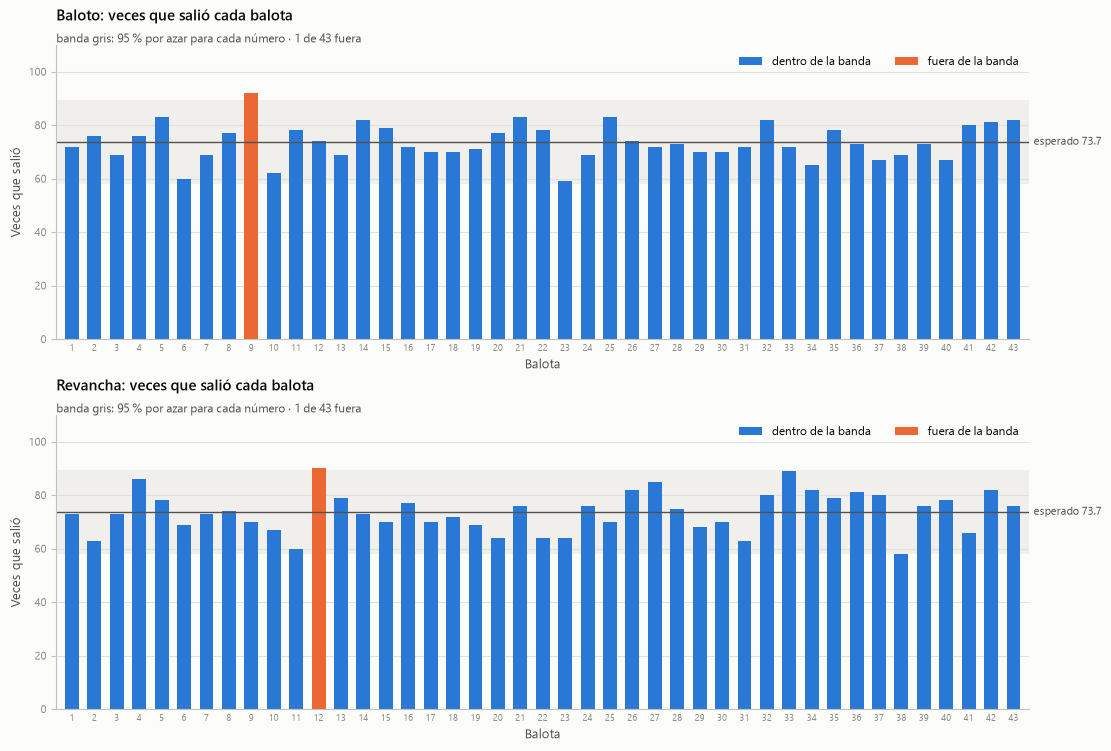

In [2]:
unif = {
    j: {
        "balotas": uniformity_balls(d.y_balls, N_SIMS, rng_for("uniformidad-balotas", j)),
        "superbalota": uniformity_super(d.y_sb, N_SIMS, rng_for("uniformidad-superbalota", j)),
    }
    for j, d in data.items()
}

fig, axes = plt.subplots(2, 1, figsize=(11, 7.4), sharey=True, layout="constrained")
for ax, (j, d) in zip(axes, data.items()):
    viz.frequency_panel(
        ax, d.y_balls.sum(axis=0), len(d), P_BALL, f"{j.capitalize()}: veces que salió cada balota"
    )
viz.save(fig, FIG / "frecuencia_balotas.png")
plt.show()

### La prueba chi-cuadrado, en tres versiones

$X^2 = \sum_j (O_j - E_j)^2 / E_j$ resume las 43 desviaciones en un solo número. La receta de libro lo compara con una $\chi^2$ de 42 grados de libertad, pero supone que las balotas son independientes entre sí, y en el Baloto **no lo son**: un sorteo no repite números, así que si sale el 7 los demás son un poco menos probables. Por eso, bajo azar, $E[X^2] = 43 - 5 = 38$ y no 42, y la receta de libro es conservadora: da p-valores demasiado altos.

| versión | cómo se calcula | para qué sirve |
|---|---|---|
| aproximada | $X^2$ frente a $\chi^2(42)$ | referencia de libro; aquí, conservadora |
| corregida | $X^2 \cdot 42/38$ frente a $\chi^2(42)$ | tiene en cuenta el muestreo sin reemplazo (asintótica) |
| Monte Carlo | $X^2$ frente a 10 000 historiales uniformes del mismo tamaño | exacta, salvo el error de simulación, que se reporta |

In [3]:
pd.DataFrame(
    [
        {
            "juego": j,
            "X²": s["chi2"],
            "p aproximado": s["p_valor_aproximado"],
            "p corregido": s["p_valor_corregido"],
            "p Monte Carlo": s["p_valor_monte_carlo"],
            "IC95 del p MC": ic(s["p_valor_monte_carlo_ic95"]),
            "E[X²] simulado": s["chi2_nulo_media"],
        }
        for j in JUEGOS
        for s in [unif[j]["balotas"].summary]
    ]
).set_index("juego")

,X²,p aproximado,p corregido,p Monte Carlo,IC95 del p MC,E[X²] simulado
juego,,,,,,
baloto,25.836,0.976,0.944,0.944,"[0.939, 0.948]",37.915
revancha,33.161,0.833,0.704,0.715,"[0.706, 0.723]",38.104


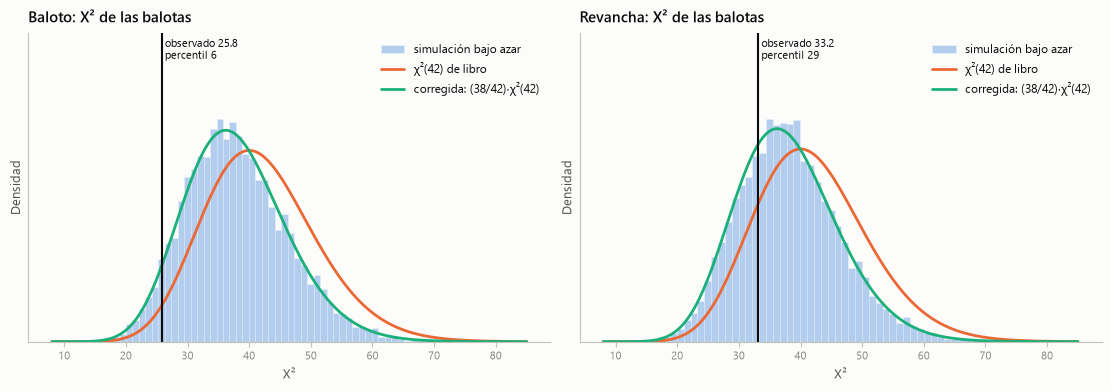

**Lectura.** La simulación confirma la teoría: bajo azar el X² se centra en 37.9 (Baloto) y 38.1 (Revancha), no en 42. La versión corregida y la Monte Carlo coinciden (Baloto: p = 0.944 y 0.944), mientras la de libro exagera el p-valor (0.976). **No hay evidencia contra la uniformidad** en ningún juego.

El X² de Baloto cae en el percentil 6 de la simulación: sus frecuencias son incluso más parejas de lo típico. Un X² demasiado *bajo* también sería sospechoso (datos "demasiado buenos para ser verdad", la crítica de Fisher a los experimentos de Mendel), pero un percentil 6 no es raro.

La balota más frecuente de Baloto es el **9** (92 veces, z = 2.26). Parece "caliente", pero con 43 números siempre hay alguno así: en los historiales simulados la mayor desviación es al menos igual de grande el 68 % de las veces.

In [4]:
xs = np.linspace(8, 85, 400)
curvas = [
    (xs, sps.chi2.pdf(xs, 42), "χ²(42) de libro", viz.ORANGE),
    (xs, (42 / 38) * sps.chi2.pdf(xs * 42 / 38, 42), "corregida: (38/42)·χ²(42)", viz.AQUA),
]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
for ax, j in zip(axes, JUEGOS):
    r = unif[j]["balotas"]
    viz.null_panel(
        ax, r.arrays["chi2"], r.summary["chi2"], f"{j.capitalize()}: X² de las balotas", "X²", curvas
    )
viz.save(fig, FIG / "chi2_nulo_balotas.png")
plt.show()

b, r = unif["baloto"]["balotas"].summary, unif["revancha"]["balotas"].summary
hot = b["balota_mas_frecuente"]
pct = 100 * np.mean(unif["baloto"]["balotas"].arrays["chi2"] <= b["chi2"])
display(Markdown(f"""**Lectura.** La simulación confirma la teoría: bajo azar el X² se centra en {b['chi2_nulo_media']:.1f} (Baloto) y {r['chi2_nulo_media']:.1f} (Revancha), no en 42. La versión corregida y la Monte Carlo coinciden (Baloto: p = {b['p_valor_corregido']:.3f} y {b['p_valor_monte_carlo']:.3f}), mientras la de libro exagera el p-valor ({b['p_valor_aproximado']:.3f}). **No hay evidencia contra la uniformidad** en ningún juego.

El X² de Baloto cae en el percentil {pct:.0f} de la simulación: sus frecuencias son incluso más parejas de lo típico. Un X² demasiado *bajo* también sería sospechoso (datos "demasiado buenos para ser verdad", la crítica de Fisher a los experimentos de Mendel), pero un percentil {pct:.0f} no es raro.

La balota más frecuente de Baloto es el **{hot['balota']}** ({hot['conteo']} veces, z = {hot['z']:.2f}). Parece "caliente", pero con 43 números siempre hay alguno así: en los historiales simulados la mayor desviación es al menos igual de grande el {100 * b['p_valor_max_abs_z_monte_carlo']:.0f} % de las veces."""))

## 2. La superbalota

Aquí sale una sola bola por sorteo, así que la chi-cuadrado clásica con 15 grados de libertad sí es válida; la versión Monte Carlo se reporta igual, como control.

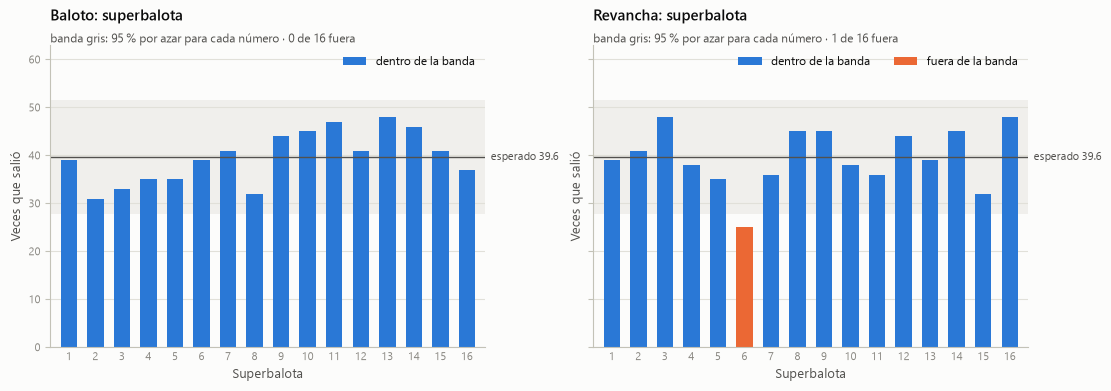

,X²,gl,p (χ²),p Monte Carlo,veredicto
juego,,,,,
baloto,11.249,15,0.735,0.725,no se rechaza H0 (p >= 0.05)
revancha,14.479,15,0.490,0.490,no se rechaza H0 (p >= 0.05)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True, layout="constrained")
for ax, (j, d) in zip(axes, data.items()):
    viz.frequency_panel(
        ax, d.y_sb.sum(axis=0), len(d), P_SUPER, f"{j.capitalize()}: superbalota", label="Superbalota"
    )
viz.save(fig, FIG / "frecuencia_superbalota.png")
plt.show()

pd.DataFrame(
    [
        {
            "juego": j,
            "X²": s["chi2"],
            "gl": s["gl"],
            "p (χ²)": s["p_valor"],
            "p Monte Carlo": s["p_valor_monte_carlo"],
            "veredicto": s["veredicto"],
        }
        for j in JUEGOS
        for s in [unif[j]["superbalota"].summary]
    ]
).set_index("juego")

## 3. ¿Baloto y Revancha son independientes?

Si los dos sorteos del mismo día son independientes, la cantidad de balotas que comparten sigue una distribución hipergeométrica: ninguna el 52 % de los días, una el 38 %, dos el 9 %..., con media 25/43 ≈ 0.581. Se comprueba de tres formas:

- **Monte Carlo** contra la hipergeométrica (supone dos sorteos justos);
- **permutación**: se barajan las fechas de Revancha y se recalcula la media. No supone nada sobre la probabilidad de cada balota: si los juegos estuvieran relacionados, emparejarlos por fecha daría algo distinto a emparejarlos al azar;
- las 43 × 43 **correlaciones** entre "salió *j* en Baloto" y "salió *k* en Revancha": la mayor en valor absoluto se compara con la mayor que aparece al permutar, lo que corrige el hecho de mirar 1849 correlaciones a la vez.

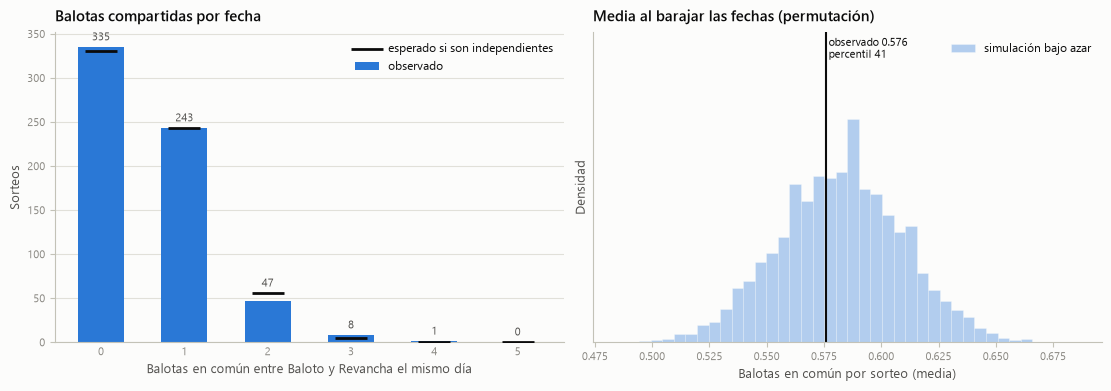

,observado,esperado,p
prueba,,,
media de balotas en común vs hipergeométrica (MC),0.576,0.581,0.831
distribución 0/1/2/3+ vs hipergeométrica (χ² MC),5.165,NaN,0.160
media de balotas en común (permutación),0.576,0.581,0.815
superbalota igual (binomial),30.000,39.625,0.119
superbalota igual (permutación),30.000,39.625,0.108
máxima |correlación| entre balotas (permutación),0.149,NaN,0.465


In [6]:
ind = independence_between_games(data["baloto"], data["revancha"], N_SIMS, rng_for("independencia"))
comun = ind.summary["balotas_en_comun"]
obs = np.array([comun["distribucion_observada"][str(k)] for k in range(6)])
esp = np.array([comun["distribucion_esperada"][str(k)] for k in range(6)])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout="constrained")
viz.common_balls_panel(axes[0], obs, esp, "Balotas compartidas por fecha")
viz.null_panel(
    axes[1],
    ind.arrays["media_permutacion"],
    comun["media_observada"],
    "Media al barajar las fechas (permutación)",
    "Balotas en común por sorteo (media)",
    bins=40,
)
viz.save(fig, FIG / "independencia_baloto_revancha.png")
plt.show()

sb, corr = ind.summary["superbalota_igual"], ind.summary["correlaciones_balotas"]
pd.DataFrame(
    [
        {"prueba": "media de balotas en común vs hipergeométrica (MC)", "observado": comun["media_observada"], "esperado": comun["media_esperada"], "p": comun["p_valor_media_monte_carlo"]},
        {"prueba": "distribución 0/1/2/3+ vs hipergeométrica (χ² MC)", "observado": comun["chi2_agrupado_0_1_2_3mas"], "esperado": np.nan, "p": comun["p_valor_chi2_monte_carlo"]},
        {"prueba": "media de balotas en común (permutación)", "observado": comun["media_observada"], "esperado": comun["media_esperada"], "p": comun["p_valor_permutacion"]},
        {"prueba": "superbalota igual (binomial)", "observado": sb["coincidencias"], "esperado": sb["esperadas"], "p": sb["p_valor_binomial"]},
        {"prueba": "superbalota igual (permutación)", "observado": sb["coincidencias"], "esperado": sb["esperadas"], "p": sb["p_valor_permutacion"]},
        {"prueba": "máxima |correlación| entre balotas (permutación)", "observado": corr["max_abs_correlacion"], "esperado": np.nan, "p": corr["p_valor_max_permutacion"]},
    ]
).set_index("prueba")

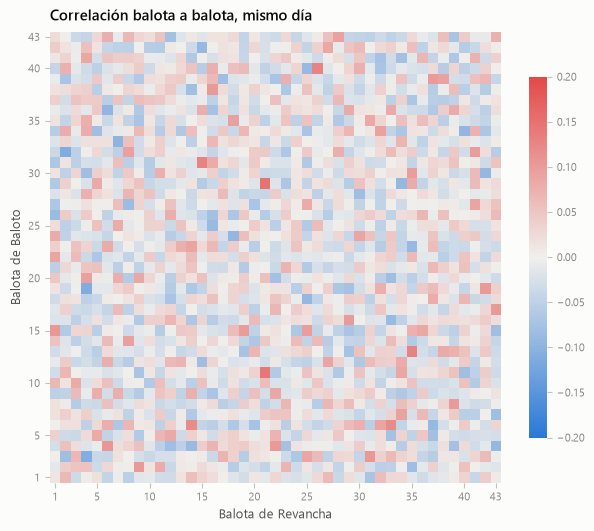

La mayor correlación en valor absoluto es 0.149. Al barajar las fechas, la mayor de las 1849 queda entre 0.126 y 0.186 el 95 % de las veces (p = 0.47): **ruido**. Tampoco hay relación en las balotas compartidas (p de permutación = 0.82) ni en la superbalota (30 coincidencias contra 39.6 esperadas, p = 0.12).

In [7]:
fig, ax = plt.subplots(figsize=(6.4, 5.2), layout="constrained")
im = viz.corr_heatmap(ax, ind.arrays["correlaciones"], "Correlación balota a balota, mismo día")
cb = fig.colorbar(im, ax=ax, shrink=0.8)
cb.outline.set_visible(False)
cb.ax.tick_params(labelsize=8, colors=viz.AXIS, labelcolor=viz.MUTED)
viz.save(fig, FIG / "correlaciones_baloto_revancha.png")
plt.show()

lo, hi = corr["max_abs_nula_ic95"]
display(Markdown(f"""La mayor correlación en valor absoluto es {corr['max_abs_correlacion']:.3f}. Al barajar las fechas, la mayor de las 1849 queda entre {lo:.3f} y {hi:.3f} el 95 % de las veces (p = {corr['p_valor_max_permutacion']:.2f}): **ruido**. Tampoco hay relación en las balotas compartidas (p de permutación = {comun['p_valor_permutacion']:.2f}) ni en la superbalota ({sb['coincidencias']} coincidencias contra {sb['esperadas']:.1f} esperadas, p = {sb['p_valor_binomial']:.2f})."""))

## 4. El listón: dos baselines en la ventana de prueba

Los modelos de las fases siguientes se evaluarán con **walk-forward**: los primeros 100 sorteos solo sirven de historia, se entrena con los 150 siguientes y desde ahí se predice cada sorteo usando solo el pasado, reentrenando cada 10. Los baselines se evalúan exactamente en la misma ventana:

- **constante**: 5/43 por balota y 1/16 por superbalota. Si el sorteo es justo, es el modelo correcto; su "top-5" es una jugada al azar (empates rotos con semilla).
- **frecuencia**: la proporción histórica de cada número antes del sorteo objetivo, suavizada hacia el uniforme.

In [8]:
ev = {j: evaluate_game(data[j], models=BASELINES) for j in JUEGOS}
filas = []
for j in JUEGOS:
    for nombre, m in ev[j]["modelos"].items():
        b, s = m["balotas"], m["superbalota"]
        filas.append(
            {
                "juego": j,
                "modelo": nombre,
                "aciertos top-5": b["aciertos_top5_media"],
                "IC95 aciertos": ic(b["aciertos_top5_ic95"]),
                "log-loss por balota": b["log_loss"],
                "skill log-loss": b["skill_log_loss"],
                "IC95 Δ log-loss": ic(b["delta_log_loss_ic95"]),
                "accuracy superbalota": s["accuracy"],
                "log-loss superbalota": s["log_loss"],
            }
        )
v, ref = ev["baloto"]["ventana"], ev["baloto"]["referencias_azar"]
display(Markdown(f"""Ventana de prueba: sorteos {v['primer_sorteo_prueba']}–{v['ultimo_sorteo_prueba']} ({v['n_sorteos_prueba']} por juego, del {v['fecha_inicio_prueba']} al {v['fecha_fin_prueba']}). Referencias por azar: {ref['aciertos_top5']:.3f} aciertos por sorteo (banda del 95 %: {ic(ref['aciertos_top5_banda95'])}), log-loss por balota {ref['log_loss_balota']:.4f}, log-loss de superbalota {ref['log_loss_superbalota']:.4f} y accuracy de superbalota {ref['accuracy_superbalota']:.4f}."""))
pd.DataFrame(filas).set_index(["juego", "modelo"])

Ventana de prueba: sorteos 2331–2714 (384 por juego, del 2023-09-23 al 2026-09-26). Referencias por azar: 0.581 aciertos por sorteo (banda del 95 %: [0.513, 0.650]), log-loss por balota 0.3594, log-loss de superbalota 2.7726 y accuracy de superbalota 0.0625.

aciertos top-5   IC95 aciertos  log-loss por balota  \
juego    modelo                                                            
baloto   constante            0.622  [0.551, 0.694]                0.359   
         frecuencia           0.529  [0.462, 0.595]                0.361   
revancha constante            0.599  [0.526, 0.672]                0.359   
         frecuencia           0.549  [0.483, 0.616]                0.361   

                     skill log-loss   IC95 Δ log-loss  accuracy superbalota  \
juego    modelo                                                               
baloto   constante       -2.220e-16  [-0.000, -0.000]                 0.049   
         frecuencia      -3.814e-03    [0.001, 0.002]                 0.057   
revancha constante       -2.220e-16  [-0.000, -0.000]                 0.068   
         frecuencia      -3.173e-03    [0.000, 0.002]                 0.062   

                     log-loss superbalota  
juego    modelo                            
baloto   constante                  2.773  
         frecuencia                 2.792  
revancha constante                  2.773  
         frecuencia                 2.782

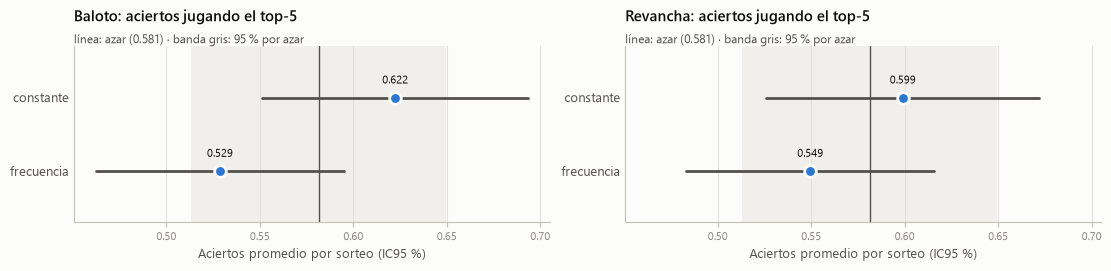

**Lectura.** Ningún baseline se sale de la banda de lo esperable por azar en aciertos. En log-loss la historia es más interesante: el baseline de frecuencia es **peor** que el constante (Baloto: Δ log-loss con IC95 [0.001, 0.002], todo por encima de cero). Es lo que predice la teoría: si el sorteo es justo, cualquier desviación del 5/43 cuesta log-loss, y "aprender" de la frecuencia pasada solo añade ruido a las probabilidades.

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 2.6), sharex=True, layout="constrained")
for ax, j in zip(axes, JUEGOS):
    mods = ev[j]["modelos"]
    viz.interval_dots(
        ax,
        list(mods),
        [m["balotas"]["aciertos_top5_media"] for m in mods.values()],
        [m["balotas"]["aciertos_top5_ic95"] for m in mods.values()],
        EXPECTED_HITS,
        ev[j]["referencias_azar"]["aciertos_top5_banda95"],
        f"{j.capitalize()}: aciertos jugando el top-5",
        "Aciertos promedio por sorteo (IC95 %)",
    )
viz.save(fig, FIG / "baselines_aciertos.png")
plt.show()

f = ev["baloto"]["modelos"]["frecuencia"]["balotas"]
display(Markdown(f"""**Lectura.** Ningún baseline se sale de la banda de lo esperable por azar en aciertos. En log-loss la historia es más interesante: el baseline de frecuencia es **peor** que el constante (Baloto: Δ log-loss con IC95 {ic(f['delta_log_loss_ic95'])}, todo por encima de cero). Es lo que predice la teoría: si el sorteo es justo, cualquier desviación del 5/43 cuesta log-loss, y "aprender" de la frecuencia pasada solo añade ruido a las probabilidades."""))

## Conclusiones

- **Uniformidad:** ni las balotas ni la superbalota muestran desviaciones mayores a las que produce el azar, en ninguno de los dos juegos.
- **Independencia:** Baloto y Revancha no comparten más (ni menos) balotas de lo esperado, y ninguna de las 1849 correlaciones balota a balota destaca sobre el ruido.
- **El listón:** en la ventana de prueba, el azar da 0.581 aciertos por sorteo jugando 5 números y una log-loss de 0.3594 por balota. Un modelo que de verdad aprendiera algo tendría que mejorar la log-loss del baseline constante fuera de muestra, con un intervalo que no cruce el cero.

Una advertencia de método: este notebook hace una decena de pruebas. Con α = 0.05, que alguna saliera "significativa" por puro azar no sería sorprendente; por eso importan tanto los controles de comparaciones múltiples (como la máxima correlación bajo permutación) como no ir probando cosas hasta que algo salga.

*Siguiente: features sin fuga de información, modelos (regresión logística y gradient boosting) y la trampa del split aleatorio.*